In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('ai_student_impact_dataset.csv')
mem_antes = df.memory_usage(deep=True).sum()
df

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,149996,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,149997,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,149998,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,149999,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [5]:
df.memory_usage(deep=True)

Index                             132
Student_ID                     400000
Major_Category                 729544
Year_of_Study                  766502
Pre_Semester_GPA               400000
Weekly_GenAI_Hours             400000
Primary_Use_Case              1349550
Prompt_Engineering_Skill       870784
Tool_Diversity                 400000
Paid_Subscription               50000
Traditional_Study_Hours        400000
Perceived_AI_Dependency        400000
Institutional_Policy          1312356
Anxiety_Level_During_Exams     400000
Post_Semester_GPA              400000
Skill_Retention_Score          400000
Burnout_Risk_Level             625919
dtype: int64

In [6]:
df = df.drop(columns=['Student_ID'])
df

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Business,Senior,2.899,12.16,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.16,High
49996,STEM,Senior,2.870,2.51,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.62,Medium
49997,Business,Senior,3.177,15.87,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.21,High
49998,Business,Junior,3.398,19.91,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.12,Medium


In [7]:
df['Primary_Use_Case'].unique()

<ArrowStringArray>
[     'Copywriting/Drafting',                  'Ideation',
       'Summarizing_Reading', 'Debugging/Troubleshooting',
  'Direct_Answer_Generation']
Length: 5, dtype: str

In [8]:
categoricas = [
    'Major_Category',
    'Year_of_Study',
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Institutional_Policy',
    'Burnout_Risk_Level'
]

for col in categoricas:
    df[col] = df[col].astype('category')

In [9]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Major_Category              50000 non-null  category
 1   Year_of_Study               50000 non-null  category
 2   Pre_Semester_GPA            50000 non-null  float64 
 3   Weekly_GenAI_Hours          50000 non-null  float64 
 4   Primary_Use_Case            50000 non-null  category
 5   Prompt_Engineering_Skill    50000 non-null  category
 6   Tool_Diversity              50000 non-null  int64   
 7   Paid_Subscription           50000 non-null  bool    
 8   Traditional_Study_Hours     50000 non-null  float64 
 9   Perceived_AI_Dependency     50000 non-null  int64   
 10  Institutional_Policy        50000 non-null  category
 11  Anxiety_Level_During_Exams  50000 non-null  int64   
 12  Post_Semester_GPA           50000 non-null  float64 
 13  Skill_Retention_Score      

In [10]:
df['Pre_Semester_GPA'].unique()

array([2.418, 3.821, 3.398, ..., 1.688, 1.467, 2.027], shape=(2389,))

fazendo um for que vai percorrer todas as colunas que tem o tipo 'int64' e tenta trocar cada uma pelo menor tipo inteiro possível sem perder informação, o mesmo acontece para o float.

In [11]:
for col in df.select_dtypes(include='int64'):
    df[col] = pd.to_numeric(df[col], downcast='integer')

for col in df.select_dtypes(include='float64'):
    df[col] = pd.to_numeric(df[col], downcast='float')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Major_Category              50000 non-null  category
 1   Year_of_Study               50000 non-null  category
 2   Pre_Semester_GPA            50000 non-null  float32 
 3   Weekly_GenAI_Hours          50000 non-null  float32 
 4   Primary_Use_Case            50000 non-null  category
 5   Prompt_Engineering_Skill    50000 non-null  category
 6   Tool_Diversity              50000 non-null  int8    
 7   Paid_Subscription           50000 non-null  bool    
 8   Traditional_Study_Hours     50000 non-null  float32 
 9   Perceived_AI_Dependency     50000 non-null  int8    
 10  Institutional_Policy        50000 non-null  category
 11  Anxiety_Level_During_Exams  50000 non-null  int8    
 12  Post_Semester_GPA           50000 non-null  float32 
 13  Skill_Retention_Score      

In [13]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798126
std,0.478854,8.269489,1.18802,5.156426,1.820812,2.144066,0.495673,13.281627
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190002
max,3.998000,40.000000,5.00000,35.860001,10.000000,10.000000,4.000000,100.000000


In [ ]:
mem_depois = df.memory_usage(deep=True).sum()

print(f"Antes: {mem_antes/1024**2:.2f} MB")
print(f"Depois: {mem_depois/1024**2:.2f} MB")

In [15]:
df.to_csv('ai_student_impact_dataset_final.csv', index=False)

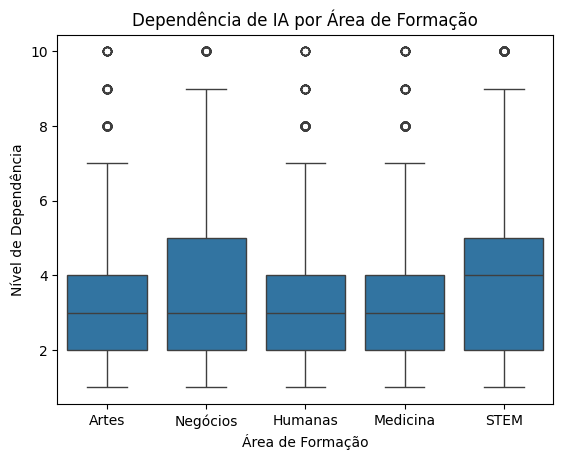

In [14]:
sns.boxplot(
    data=df,
    x='Major_Category',
    y='Perceived_AI_Dependency'
)

plt.xticks(
    ticks=[0,1,2,3,4],
    labels=['Artes', 'Negócios', 'Humanas', 'Medicina', 'STEM']
)

plt.title('Dependência de IA por Área de Formação')
plt.xlabel('Área de Formação')
plt.ylabel('Nível de Dependência')

plt.show()

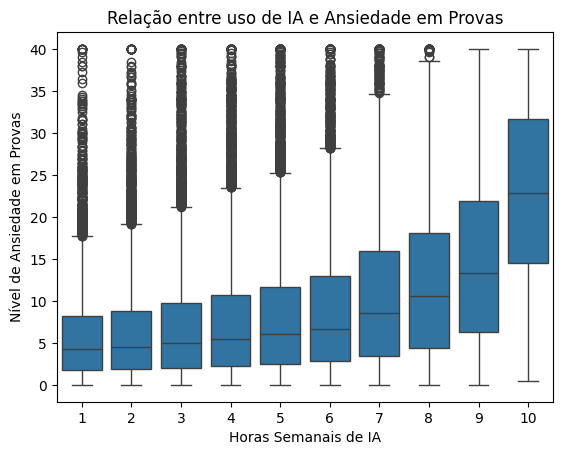

In [16]:
sns.boxplot(
    data=df,
    x='Anxiety_Level_During_Exams',
    y='Weekly_GenAI_Hours'
)

plt.xlabel('Horas Semanais de IA')
plt.ylabel('Nível de Ansiedade em Provas')
plt.title('Relação entre uso de IA e Ansiedade em Provas')

plt.show()

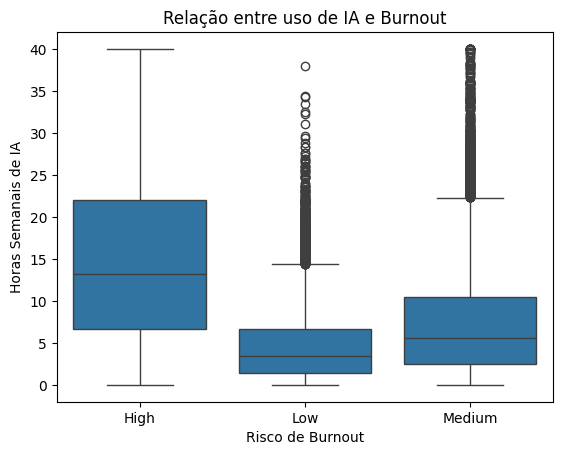

In [17]:
sns.boxplot(
    data = df,
    x = 'Burnout_Risk_Level',
    y = 'Weekly_GenAI_Hours'
)

plt.xlabel('Risco de Burnout')
plt.ylabel('Horas Semanais de IA')
plt.title('Relação entre uso de IA e Burnout')

plt.show()

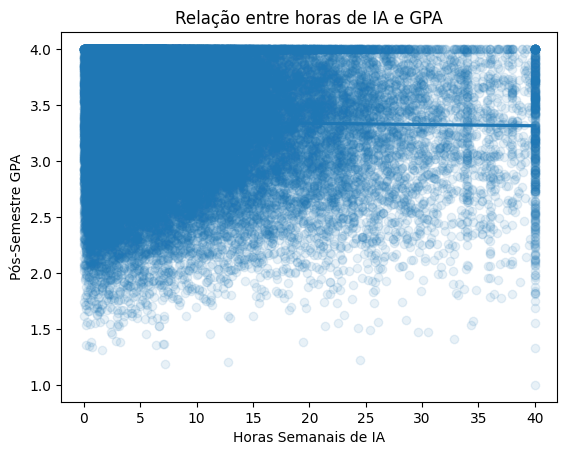

In [18]:
sns.regplot(
    data=df,
    x='Weekly_GenAI_Hours',
    y='Post_Semester_GPA',
    scatter_kws={'alpha':0.1}
)

plt.xlabel('Horas Semanais de IA')
plt.ylabel('Pós-Semestre GPA')
plt.title('Relação entre horas de IA e GPA')

plt.show()

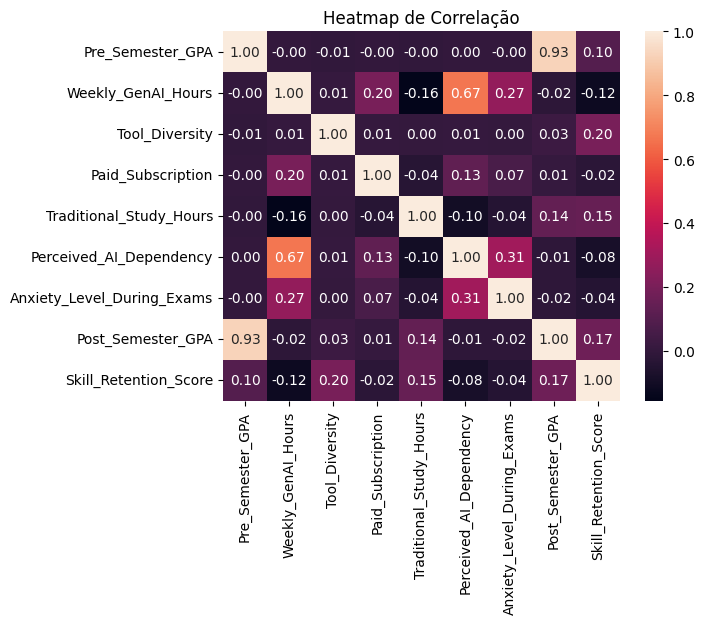

In [19]:
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f'
)

plt.title('Heatmap de Correlação')

plt.show()

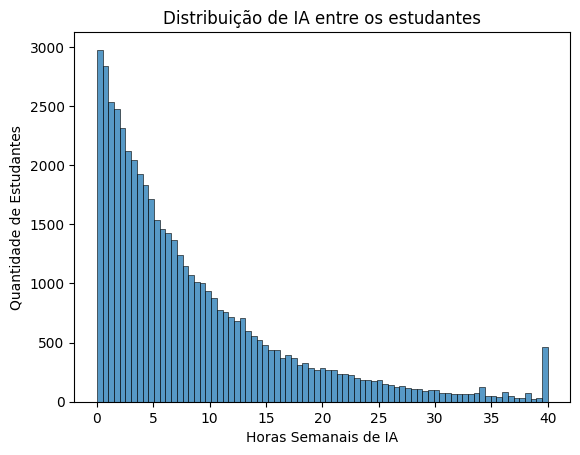

In [20]:
sns.histplot(
    data=df,
    x='Weekly_GenAI_Hours'
)

plt.xlabel('Horas Semanais de IA')
plt.ylabel('Quantidade de Estudantes')
plt.title('Distribuição de IA entre os estudantes')

plt.show()